In [1]:
import sys
import os
import subprocess
import json

sys.path.append('/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/SRC/')

from decisao_multicriterio.MCDA_DecisaoSubjetiva import *
from decisao_multicriterio.MCDA_DecisaoDados import *

Executando '/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/SRC/modelos_matematicos/pareto_despacho_economico.jl' via subprocesso...
Execução concluída com sucesso:

--- Fronteira de Pareto ---
w_c=1.0, w_e=0.0 -> Custo=13290.0 USD, Emissões=2566.0 tCO2
w_c=0.9, w_e=0.1 -> Custo=14260.0 USD, Emissões=2178.0 tCO2
w_c=0.8, w_e=0.2 -> Custo=19520.0 USD, Emissões=1020.8 tCO2
w_c=0.7, w_e=0.3 -> Custo=19520.0 USD, Emissões=1020.8 tCO2
w_c=0.6, w_e=0.4 -> Custo=19520.0 USD, Emissões=1020.8 tCO2
w_c=0.5, w_e=0.5 -> Custo=20490.0 USD, Emissões=982.0 tCO2
w_c=0.4, w_e=0.6 -> Custo=20490.0 USD, Emissões=982.0 tCO2
w_c=0.3, w_e=0.7 -> Custo=20490.0 USD, Emissões=982.0 tCO2
w_c=0.2, w_e=0.8 -> Custo=20490.0 USD, Emissões=982.0 tCO2
w_c=0.1, w_e=0.9 -> Custo=20490.0 USD, Emissões=982.0 tCO2
w_c=0.0, w_e=1.0 -> Custo=20490.0 USD, Emissões=982.0 tCO2
Gráfico salvo como pareto.png



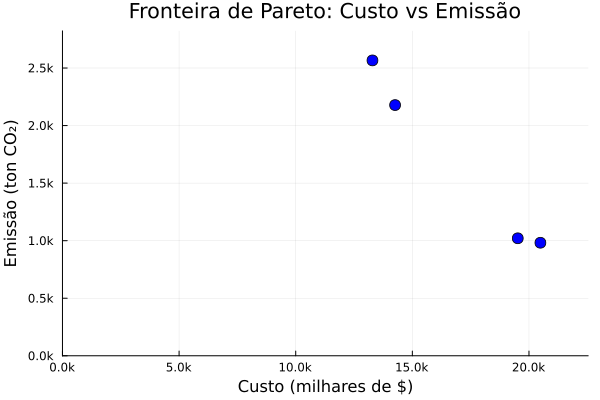

In [2]:
# Caminho para o script Julia
script = "pareto_despacho_economico"    
script_julia = "/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/SRC/modelos_matematicos/"+script+".jl"

if not os.path.exists(script_julia):
    print(f"Arquivo Julia '{script_julia}' não encontrado.")
    sys.exit(1)
else:
    # Comando para executar
    comando = ["julia", script_julia]
    print(f"Executando '{script_julia}' via subprocesso...")

    # Executa e captura a saída
    try:
        resultado = subprocess.run(comando, capture_output=True, text=True, check=True)
        print("Execução concluída com sucesso:")
        print(resultado.stdout)
    except subprocess.CalledProcessError as e:
        print("Erro durante a execução do script Julia:")
        print(e.stderr)

from IPython.display import Image
Image(filename='/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/relatorios/pareto.png')

In [3]:
# Lendo do arquivo JSON
with open('/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/DATA/output/input_alternativas.json', 'r', encoding='utf-8') as file:
    DADOS = json.load(file)

DATA = f'''{json.dumps(DADOS, indent=2)}'''
# Matriz de critérios para WASPAS (exemplo simplificado)
matriz_criterios = pd.DataFrame({
    'Custo Operacao': [1, 2],
    'Emissao ton CO2': [1/2, 1]
})


In [4]:
ahp_gauss = AHP_Gaussiano(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios (AHP-Gaussiano):
Custo Operacao     0.514
Emissao ton CO2    0.486
dtype: float64

Ranking das Alternativas: - (AHP-Gaussiano)
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               4  w_c=0.5, w_e=0.5         20490.0            982.0  0.270
1               3  w_c=0.8, w_e=0.2         19520.0           1020.8  0.269
2               1  w_c=1.0, w_e=0.0         13290.0           2566.0  0.231
3               2  w_c=0.9, w_e=0.1         14260.0           2178.0  0.230


In [5]:
lopcow = LOPCOW(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios LOPCOW:
Custo Operacao     0.453
Emissao ton CO2    0.547
dtype: float64

Ranking das Alternativas: - LOPCOW
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               3  w_c=0.8, w_e=0.2         19520.0           1020.8  0.280
1               4  w_c=0.5, w_e=0.5         20490.0            982.0  0.258
2               2  w_c=0.9, w_e=0.1         14260.0           2178.0  0.248
3               1  w_c=1.0, w_e=0.0         13290.0           2566.0  0.214


In [6]:
mpsi = MPSI(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios MPSI:
Custo Operacao     0.226
Emissao ton CO2    0.774
dtype: float64

Ranking das Alternativas: - MPSI
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               4  w_c=0.5, w_e=0.5         20490.0            982.0  0.317
1               3  w_c=0.8, w_e=0.2         19520.0           1020.8  0.310
2               2  w_c=0.9, w_e=0.1         14260.0           2178.0  0.193
3               1  w_c=1.0, w_e=0.0         13290.0           2566.0  0.180


In [7]:
# Métodos SUBJETIVOS
ahp = AHP(arquivo_alternativas= DATA).rank_alternativas(matriz_criterios=matriz_criterios)


--------------------------------------------------------------------------------
Pesos dos critérios (AHP):
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - AHP
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               1  w_c=1.0, w_e=0.0         13290.0           2566.0  0.256
1               3  w_c=0.8, w_e=0.2         19520.0           1020.8  0.249
2               2  w_c=0.9, w_e=0.1         14260.0           2178.0  0.248
3               4  w_c=0.5, w_e=0.5         20490.0            982.0  0.247


In [8]:
waspas = WASPAS(arquivo_alternativas= DATA).rank_alternativas(matriz_criterios=matriz_criterios)


--------------------------------------------------------------------------------
Pesos dos critérios WASPAS:
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - WASPAS 
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               3  w_c=0.8, w_e=0.2         19520.0           1020.8  0.253
1               1  w_c=1.0, w_e=0.0         13290.0           2566.0  0.250
2               4  w_c=0.5, w_e=0.5         20490.0            982.0  0.249
3               2  w_c=0.9, w_e=0.1         14260.0           2178.0  0.247


In [9]:
wisp = WISP(arquivo_alternativas=DATA).rank_alternativas(matriz_criterios=matriz_criterios)

--------------------------------------------------------------------------------
Pesos dos critérios WISP:
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - WISP
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               3  w_c=0.8, w_e=0.2         19520.0           1020.8  0.488
1               4  w_c=0.5, w_e=0.5         20490.0            982.0  0.351
2               2  w_c=0.9, w_e=0.1         14260.0           2178.0  0.161
3               1  w_c=1.0, w_e=0.0         13290.0           2566.0  0.000


In [10]:
df_ahp = ahp.rename(columns={"Score": "AHP"})
df_waspas = waspas.rename(columns={"Score": "WASPAS"})
df_wisp = wisp.rename(columns={"Score": "WISP"})
df_ahp_gauss = ahp_gauss.rename(columns={"Score": "AHP_Gaussiano"})
df_lopcow = lopcow.rename(columns={"Score": "LOPCOW"})
df_mpsi = mpsi.rename(columns={"Score": "MPSI"})
# Seleciona colunas-chave
base_cols = ["id_alternativa", "descricao"]


df_merged = df_ahp_gauss[base_cols + ["AHP_Gaussiano"]] \
    .merge(df_lopcow[base_cols + ["LOPCOW"]], on=base_cols, how="outer") \
    .merge(df_mpsi[base_cols + ["MPSI"]], on=base_cols, how="outer") \
    .merge(df_ahp[base_cols + ["AHP"]], on=base_cols, how="outer") \
    .merge(df_waspas[base_cols + ["WASPAS"]], on=base_cols, how="outer") \
    # .merge(df_wisp[base_cols + ["WISP"]], on=base_cols, how="outer")

# Ordena por uma média dos scores
df_merged = df_merged.fillna(0)
df_merged["Score_Medio"] = df_merged[["AHP_Gaussiano","LOPCOW", "MPSI","AHP","WASPAS"]].mean(axis=1)
df_merged = df_merged.sort_values(by="Score_Medio", ascending=False).reset_index(drop=True)

print('-'*90)
df_merged

------------------------------------------------------------------------------------------


,id_alternativa,descricao,AHP_Gaussiano,LOPCOW,MPSI,AHP,WASPAS,Score_Medio
0,3,"w_c=0.8, w_e=0.2",0.269,0.280,0.310,0.249,0.253,0.2722
1,4,"w_c=0.5, w_e=0.5",0.270,0.258,0.317,0.247,0.249,0.2682
2,2,"w_c=0.9, w_e=0.1",0.230,0.248,0.193,0.248,0.247,0.2332
3,1,"w_c=1.0, w_e=0.0",0.231,0.214,0.180,0.256,0.250,0.2262
